In [1]:
import numpy as np
import load_problem as ld
import plotter as pl
import minimize as mn
import connect as ct
import row_normalization as rn
import symmetrize as sy
import adjacency as adj
import normalize as nr
import spectral as sp
import eigen_solver as es
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import normalized_mutual_info_score
%matplotlib inline

In [2]:
def subspace_clustering(problem, ground_truth, set_gamma=0.001,
                        set_K=0,
                        norm_sub=False,
                        plotter=False,
                        extra_plotter=False,
                        printer=False,
                        save_figure=False,
                        axis_hold=False):
    """perform subspace clustering
    keyword arguments:
        problem: to cluster
        ground_truth: of the problem
        set_gamma: convex factor
        set_K: sets the number of K's <- beeter desc
        norm_sub: norilize matrix or not
        plotter: plot the problem default=False
        final_plotter : plot the mutual connections and final plot after k_means
        printer: print out statments for debugging default=False
    returns:
        normalized mutual information score
    """
    S, gt, k = ld.load_problem(problem, ground_truth, printer, plotter, False, axis_hold)
            
    # begin subspace clustering
    
    coeff, A = mn.minimize(S, set_gamma, printer)
    
#     if norm_sub: coeff = rn.row_normalizer(coeff, printer)

    coeff = sy.symmetrize(coeff, printer)

    newcoeff = adj.adjacency(coeff, set_K, A, printer)

#     if norm_sub: newcoeff = rn.row_normalizer(newcoeff, printer)
    
    newcoeff = sy.symmetrize(newcoeff, printer)
    
    # perform spectral clustering
    
    L = sp.subspace_spectral(newcoeff, printer, plotter)
    
    X, Y = es.eigen_solver(L, k, printer, extra_plotter)
    
    # perform kmeans
    kmeans = KMeans(n_clusters=k, max_iter=1000, n_init=20).fit(Y)
          
    # calculate the normalized mutual information score
    nmi = normalized_mutual_info_score(gt, kmeans.labels_)
    print(problem, 'gamma:', round(set_gamma, 3), 'normalized mutual information score:', round(nmi, 3), '\n')
    
    if plotter:
        if S.shape[1] == 2:           
            prob_type = 'subspace'
            prob_title = str(problem)
            pl.plotter(S, kmeans.labels_, nmi, prob_type, prob_title, set_gamma, printer, save_figure, axis_hold)
            ct.connect(S, gt, L, kmeans.labels_, nmi, prob_type, prob_title, set_gamma, printer, save_figure, axis_hold)

In [3]:
set_K = 0
gamma = np.linspace(0.001,1,5)
plotter = False
printer = False
norm_sub = False
extra_plotter = False
for i in gamma:
    subspace_clustering('../05_toy_problems/01_simple_two_and_two.tp',
                        '../05_toy_problems/01_simple_two_and_two_ground_truth.tp',
                        i, set_K, norm_sub, plotter, extra_plotter, printer)

../05_toy_problems/01_simple_two_and_two.tp gamma: 0.001 normalized mutual information score: 0.0 

../05_toy_problems/01_simple_two_and_two.tp gamma: 0.251 normalized mutual information score: 1.0 

../05_toy_problems/01_simple_two_and_two.tp gamma: 0.5 normalized mutual information score: 0.344 

../05_toy_problems/01_simple_two_and_two.tp gamma: 0.75 normalized mutual information score: 0.344 

../05_toy_problems/01_simple_two_and_two.tp gamma: 1.0 normalized mutual information score: 0.344 



problem:
[[1. 1.]
 [1. 2.]
 [9. 8.]
 [9. 9.]] 

problem size: 4 x 2 

len ground truth: 4 

ground truth:
[[0]
 [0]
 [1]
 [1]] 

number of clusters n: 2 



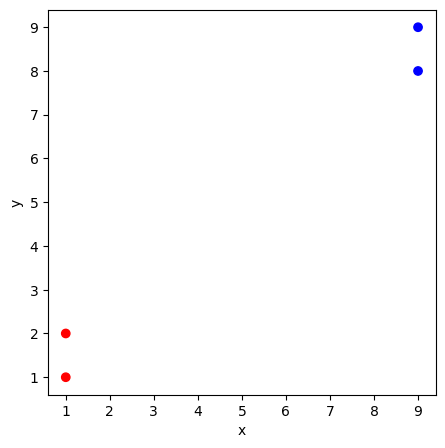

A =
[[1. 1. 9. 9.]
 [1. 2. 8. 9.]] 

shape of A = (2, 4) 

coeff =
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] 


************************************************
            Solve for coefficents
b =
 [1. 1.]
coeff =
[[8.29840543e-16 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [5.10110983e-12 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.47223826e-11 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.11111111e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00]] 

b =
 [1. 2.]
coeff =
[[8.29840543e-16 2.38273156e-11 0.00000000e+00 0.00000000e+00]
 [5.10110983e-12 4.05383220e-15 0.00000000e+00 0.00000000e+00]
 [1.47223826e-11 4.61133638e-11 0.00000000e+00 0.00000000e+00]
 [1.11111111e-01 1.42934703e-01 0.00000000e+00 0.00000000e+00]] 

b =
 [9. 8.]
coeff =
[[8.29840543e-16 2.38273156e-11 1.02846792e-10 0.00000000e+00]
 [5.10110983e-12 4.05383220e-15 2.93458412e-11 0.00000000e+00]
 [1.47223826e-11 4.61133638e-11 8.21652604e-15 0.00000000e+00]
 [1.11111111e-01 1.42934

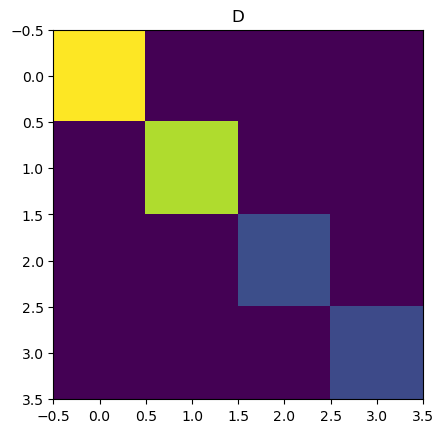

L matrix, L:
[[0.00000000e+00 2.29549952e-10 2.52737822e-10 2.24651744e-01]
 [2.29549952e-10 0.00000000e+00 1.43020700e-10 2.54800275e-01]
 [2.52737822e-10 1.43020700e-10 0.00000000e+00 9.40536237e-01]
 [2.24651744e-01 2.54800275e-01 9.40536237e-01 0.00000000e+00]] 



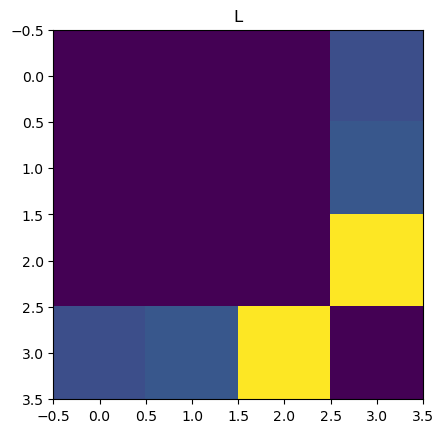

end spectral method 

eigenvalues:
[-1.00000000e+00 -2.27849202e-10  2.62166946e-11  1.00000000e+00] 

eigenvectors:
[[-1.58852772e-01 -7.62719389e-01 -6.06457523e-01  1.58852772e-01]
 [-1.80171002e-01  6.46691853e-01 -7.18934258e-01  1.80171002e-01]
 [-6.65059551e-01  6.98429161e-03  3.39621563e-01  6.65059551e-01]
 [ 7.07106781e-01  1.04925581e-10  2.81755142e-10  7.07106781e-01]] 



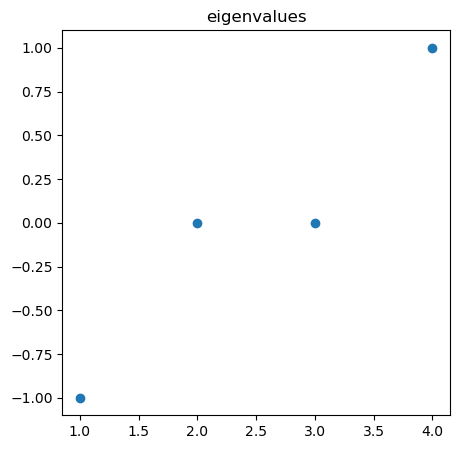

top k egienvectors:
[-1, -2] 

top k egienvectors stacked in columns, X:
[[ 1.58852772e-01 -6.06457523e-01]
 [ 1.80171002e-01 -7.18934258e-01]
 [ 6.65059551e-01  3.39621563e-01]
 [ 7.07106781e-01  2.81755142e-10]] 

X squared:
[[2.52342032e-02 3.67790727e-01]
 [3.24615900e-02 5.16866467e-01]
 [4.42304207e-01 1.15342806e-01]
 [5.00000000e-01 7.93859603e-20]] 

X squared row sum:
[[0.39302493]
 [0.54932806]
 [0.55764701]
 [0.5       ]] 

[[0.626917  ]
 [0.74116669]
 [0.74675767]
 [0.70710678]] 

renormalized matrix, Y:
[[ 2.53387244e-01 -9.67364928e-01]
 [ 2.43091069e-01 -9.70003470e-01]
 [ 8.90596215e-01  4.54794879e-01]
 [ 1.00000000e+00  3.98461944e-10]] 



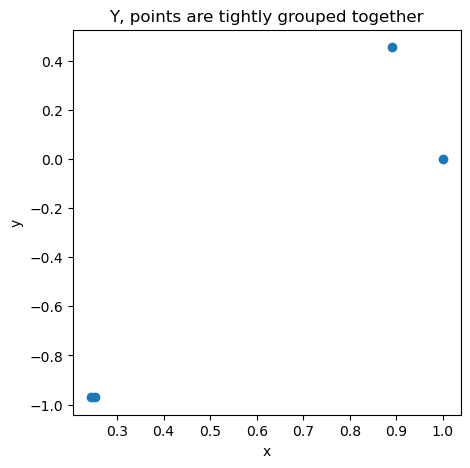

../05_toy_problems/01_simple_two_and_two.tp gamma: 0.2 normalized mutual information score: 1.0 


labels to be checked:
[1 1 0 0] 

labels returned:
[0 0 1 1] 

k-means labels are:
[[0]
 [0]
 [1]
 [1]] 



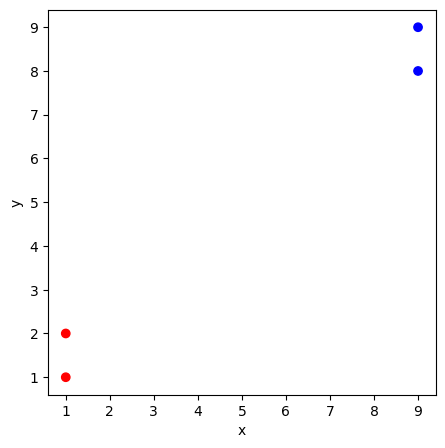


labels to be checked:
[0 0 1 1] 

labels returned:
[0 0 1 1] 



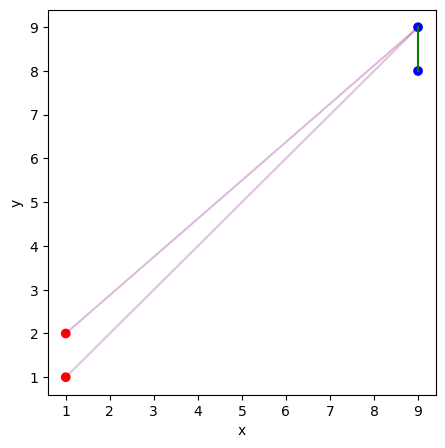

In [4]:
set_k = 0
gamma = 0.2
plotter = True
printer = True
norm_sub = False
extra_plotter = True
save = True
axis_hold = False
subspace_clustering('../05_toy_problems/01_simple_two_and_two.tp',
                    '../05_toy_problems/01_simple_two_and_two_ground_truth.tp',
                    gamma, set_k, norm_sub, plotter, extra_plotter, printer, save, axis_hold)

In [8]:
set_K = 0
gamma = np.linspace(0.001,1,50)
plotter = False
printer = False
norm_sub = False
extra_plotter = False
for i in gamma:
    subspace_clustering('../05_toy_problems/02_simple_four_and_four.tp',
                        '../05_toy_problems/02_simple_four_and_four_ground_truth.tp',
                        i, set_K, norm_sub, plotter, extra_plotter, printer)

../05_toy_problems/02_simple_four_and_four.tp gamma: 0.001 normalized mutual information score: 0.179 

../05_toy_problems/02_simple_four_and_four.tp gamma: 0.021 normalized mutual information score: 0.0 

../05_toy_problems/02_simple_four_and_four.tp gamma: 0.042 normalized mutual information score: 0.344 

../05_toy_problems/02_simple_four_and_four.tp gamma: 0.062 normalized mutual information score: 0.562 

../05_toy_problems/02_simple_four_and_four.tp gamma: 0.083 normalized mutual information score: 0.344 

../05_toy_problems/02_simple_four_and_four.tp gamma: 0.103 normalized mutual information score: 0.0 

../05_toy_problems/02_simple_four_and_four.tp gamma: 0.123 normalized mutual information score: 0.0 

../05_toy_problems/02_simple_four_and_four.tp gamma: 0.144 normalized mutual information score: 0.0 

../05_toy_problems/02_simple_four_and_four.tp gamma: 0.164 normalized mutual information score: 0.0 

../05_toy_problems/02_simple_four_and_four.tp gamma: 0.184 normalized mutu

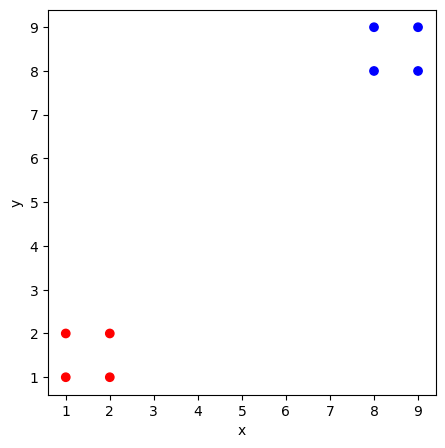

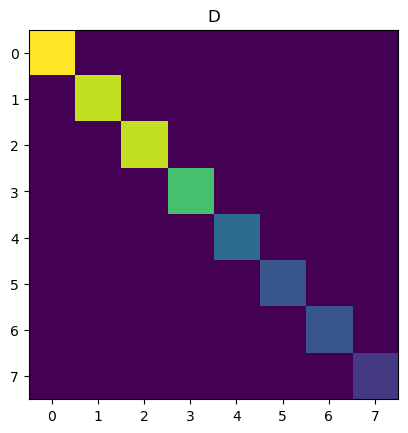

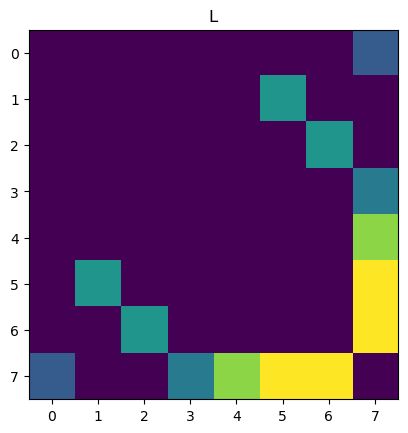

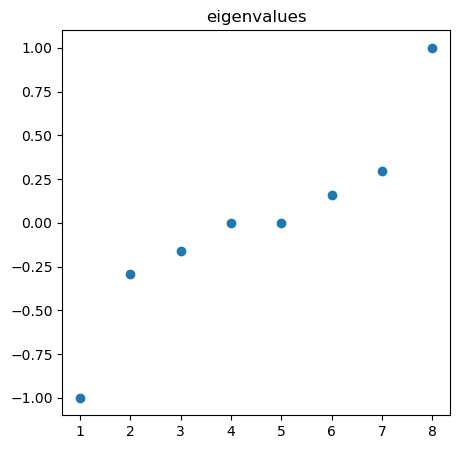

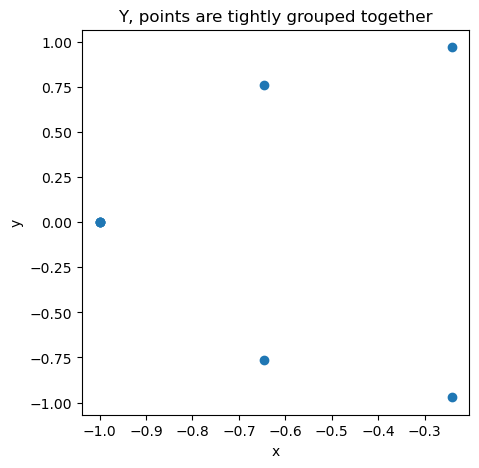

../05_toy_problems/02_simple_four_and_four.tp gamma: 0.123 normalized mutual information score: 0.0 



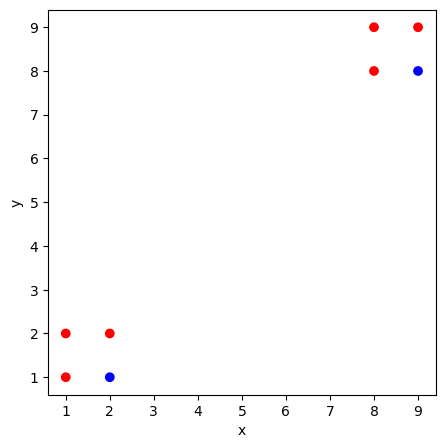

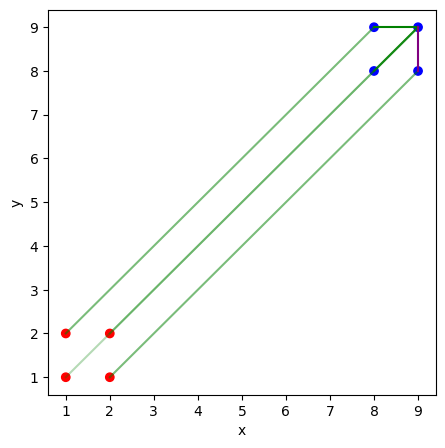

In [9]:
set_k = 0
gamma = 0.123
plotter = True
printer = False
norm_sub = False
extra_plotter = True
save = True
axis_hold = False
subspace_clustering('../05_toy_problems/02_simple_four_and_four.tp',
                    '../05_toy_problems/02_simple_four_and_four_ground_truth.tp',
                    gamma, set_k, norm_sub, plotter, extra_plotter, printer, save, axis_hold)

In [10]:
set_K = 0
gamma = np.linspace(0.001,0.1,50)
plotter = False
printer = False
norm_sub = False
extra_plotter = False
for i in gamma:
    subspace_clustering('../05_toy_problems/04_two_horizontal_lines_0_to_1.tp',
                        '../05_toy_problems/03_ground_truth.tp',
                        i, set_K, norm_sub, plotter, extra_plotter, printer)

../05_toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.001 normalized mutual information score: 0.015 

../05_toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.003 normalized mutual information score: 0.46 

../05_toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.005 normalized mutual information score: 0.289 

../05_toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.007 normalized mutual information score: 0.115 

../05_toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.009 normalized mutual information score: 0.488 

../05_toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.011 normalized mutual information score: 0.114 

../05_toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.013 normalized mutual information score: 0.137 

../05_toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.015 normalized mutual information score: 0.695 

../05_toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.017 normalized mutual information score: 0.03 

../

KeyboardInterrupt: 

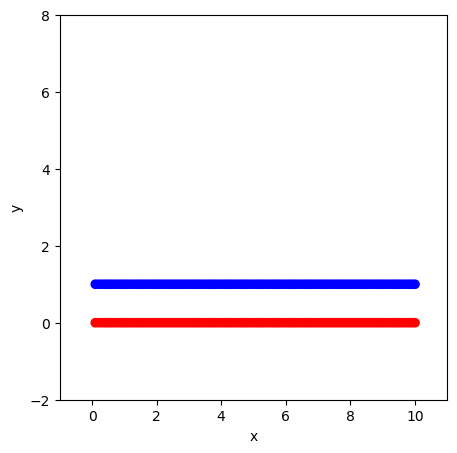

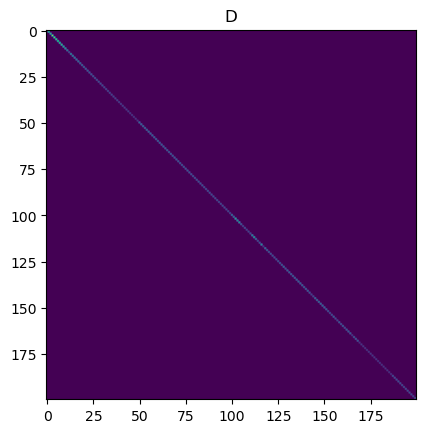

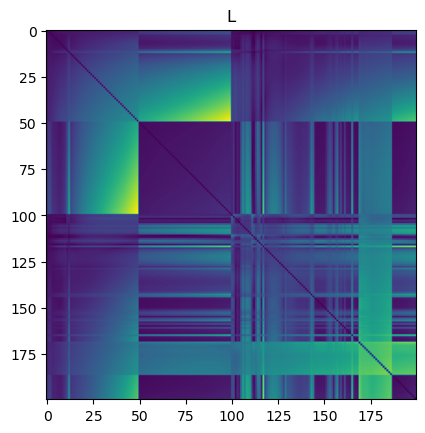

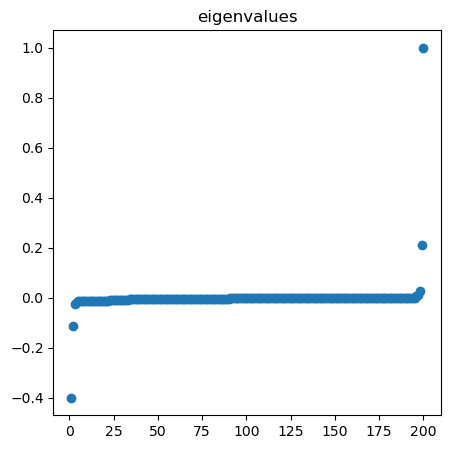

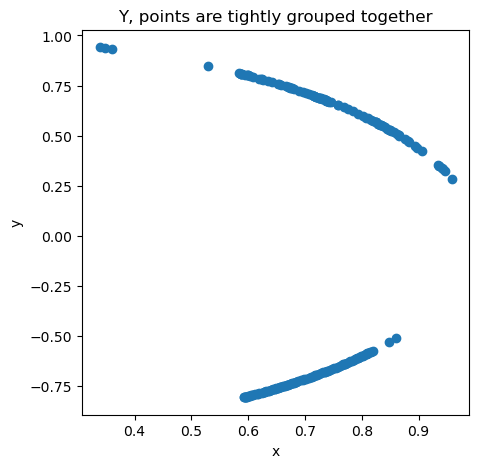

../05_toy_problems/04_two_horizontal_lines_0_to_1.tp gamma: 0.058 normalized mutual information score: 1.0 



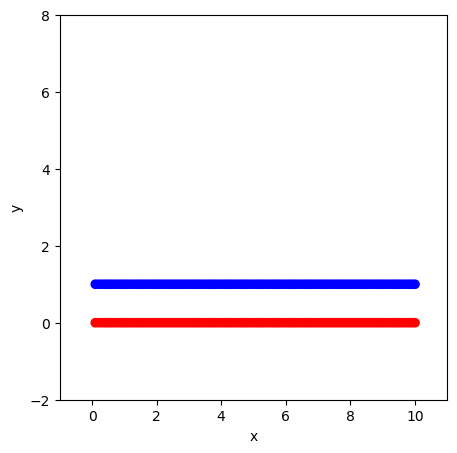

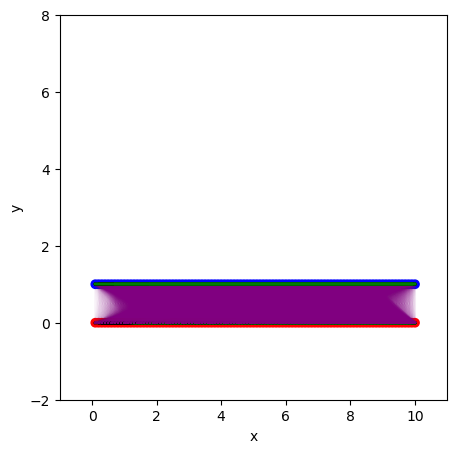

In [11]:
set_K = 0
gamma = 0.058
plotter = True
printer = False
norm_sub = False
extra_plotter = True
save = True
axis_hold = True
subspace_clustering('../05_toy_problems/04_two_horizontal_lines_0_to_1.tp',
                    '../05_toy_problems/03_ground_truth.tp',
                    gamma, set_K, norm_sub, plotter, extra_plotter, printer, save, axis_hold)

In [13]:
set_K = 0
gamma = np.linspace(0.001,1,5)
plotter = False
printer = False
norm_sub = False
extra_plotter = False
for i in gamma:
    subspace_clustering('../05_toy_problems/05_two_horizontal_lines_0_to_4.tp',
                        '../05_toy_problems/03_ground_truth.tp',
                        i, set_K, norm_sub, plotter, extra_plotter, printer)

../05_toy_problems/05_two_horizontal_lines_0_to_4.tp gamma: 0.001 normalized mutual information score: 0.721 

../05_toy_problems/05_two_horizontal_lines_0_to_4.tp gamma: 0.251 normalized mutual information score: 1.0 

../05_toy_problems/05_two_horizontal_lines_0_to_4.tp gamma: 0.5 normalized mutual information score: 1.0 

../05_toy_problems/05_two_horizontal_lines_0_to_4.tp gamma: 0.75 normalized mutual information score: 1.0 

../05_toy_problems/05_two_horizontal_lines_0_to_4.tp gamma: 1.0 normalized mutual information score: 1.0 



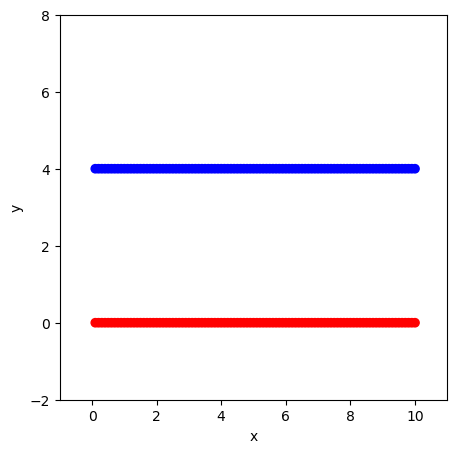

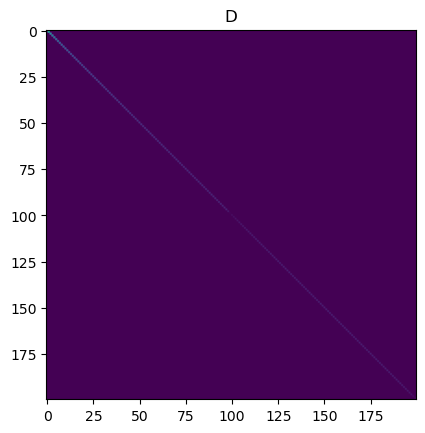

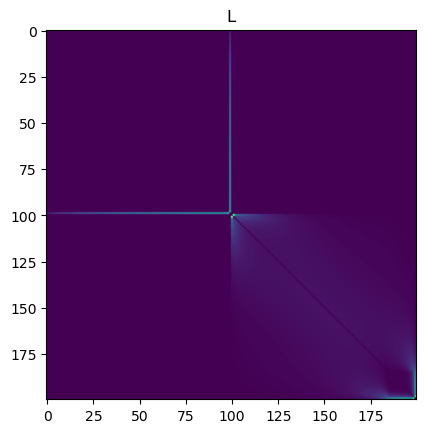

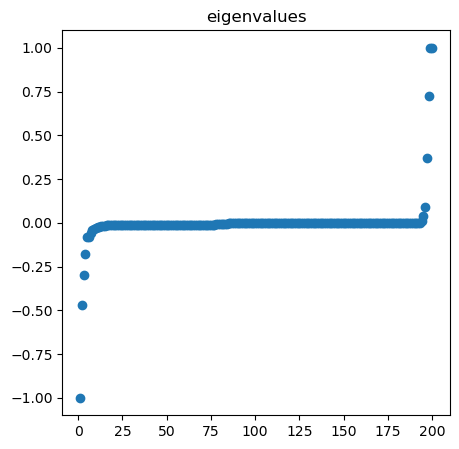

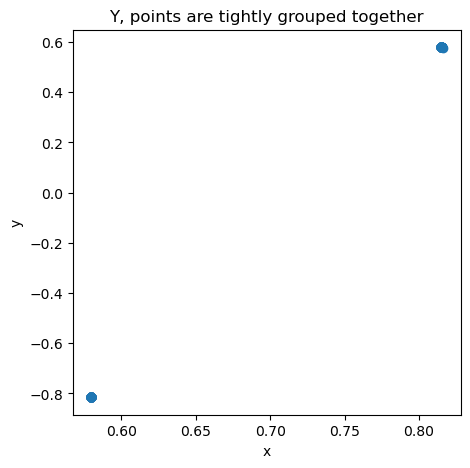

../05_toy_problems/05_two_horizontal_lines_0_to_4.tp gamma: 0.5 normalized mutual information score: 1.0 



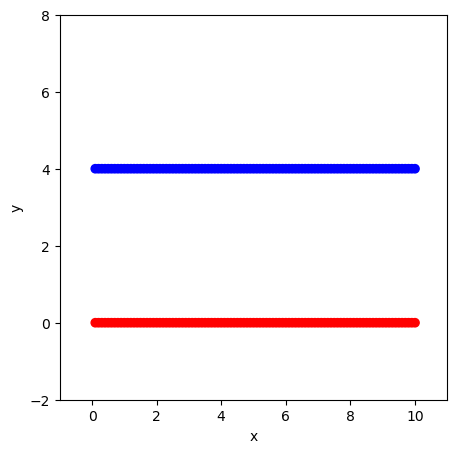

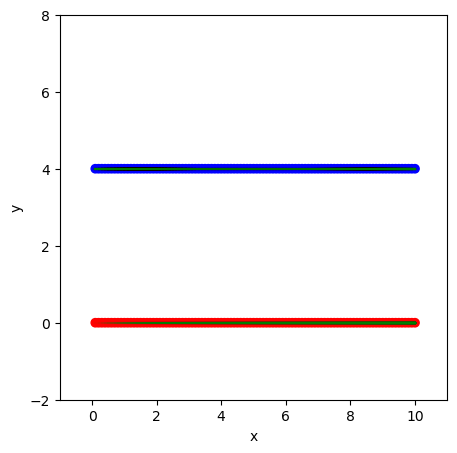

In [14]:
set_K = 0
gamma = 0.5
plotter = True
printer = False
norm_sub = False
extra_plotter = True
save = True
axis_hold = True
subspace_clustering('../05_toy_problems/05_two_horizontal_lines_0_to_4.tp',
                    '../05_toy_problems/03_ground_truth.tp',
                    gamma, set_K, norm_sub, plotter, extra_plotter, printer, save, axis_hold)

In [15]:
set_K = 0
gamma = np.linspace(0.001,1,5)
plotter = False
printer = False
norm_sub = False
extra_plotter = False
for i in gamma:
    subspace_clustering('../05_toy_problems/06_two_horizontal_lines_0_to_5.tp',
                        '../05_toy_problems/03_ground_truth.tp',
                        i, set_K, norm_sub, plotter, extra_plotter, printer)

../05_toy_problems/06_two_horizontal_lines_0_to_5.tp gamma: 0.001 normalized mutual information score: 0.835 

../05_toy_problems/06_two_horizontal_lines_0_to_5.tp gamma: 0.251 normalized mutual information score: 1.0 

../05_toy_problems/06_two_horizontal_lines_0_to_5.tp gamma: 0.5 normalized mutual information score: 1.0 

../05_toy_problems/06_two_horizontal_lines_0_to_5.tp gamma: 0.75 normalized mutual information score: 1.0 

../05_toy_problems/06_two_horizontal_lines_0_to_5.tp gamma: 1.0 normalized mutual information score: 1.0 



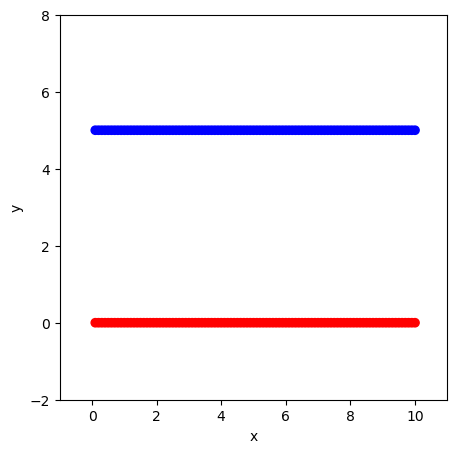

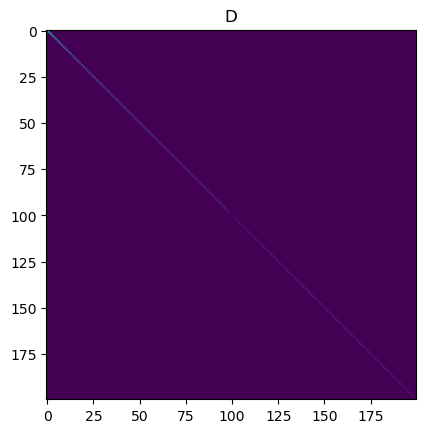

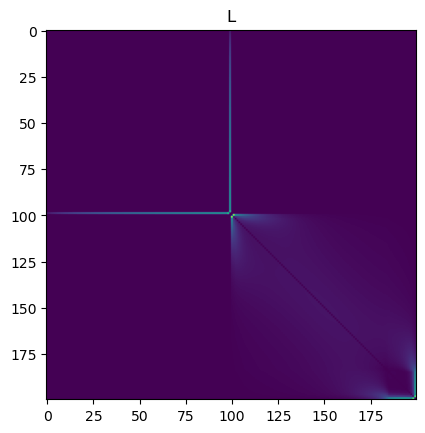

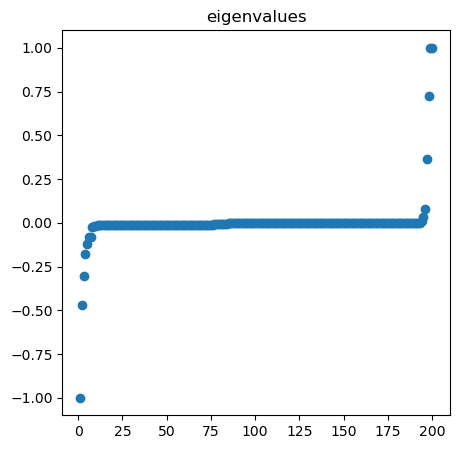

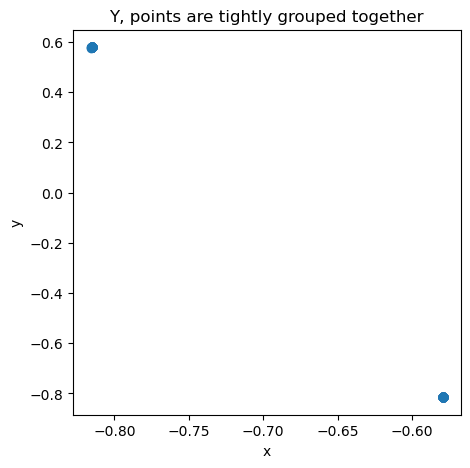

../05_toy_problems/06_two_horizontal_lines_0_to_5.tp gamma: 0.5 normalized mutual information score: 1.0 



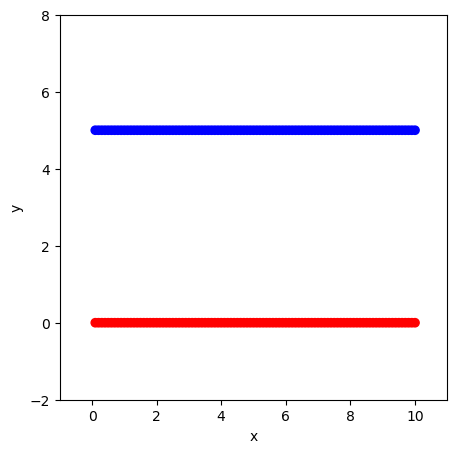

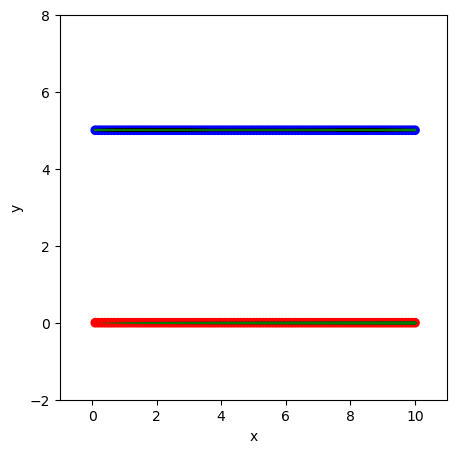

In [16]:
set_K = 0
gamma = 0.5
plotter = True
printer = False
norm_sub = False
extra_plotter = True
save = True
axis_hold = True
subspace_clustering('../05_toy_problems/06_two_horizontal_lines_0_to_5.tp',
                    '../05_toy_problems/03_ground_truth.tp',
                    gamma, set_K, norm_sub, plotter, extra_plotter, printer, save, axis_hold)

In [17]:
set_K = 0
gamma = np.linspace(.001,.5,5)
plotter = False
printer = False
norm_sub = False
extra_plotter = False
for i in gamma:
    subspace_clustering('../05_toy_problems/07_two_interlocking_circles.tp',
                        '../05_toy_problems/03_ground_truth.tp',
                        i, set_K, norm_sub, plotter, extra_plotter, printer)

../05_toy_problems/07_two_interlocking_circles.tp gamma: 0.001 normalized mutual information score: 0.069 

../05_toy_problems/07_two_interlocking_circles.tp gamma: 0.126 normalized mutual information score: 0.001 

../05_toy_problems/07_two_interlocking_circles.tp gamma: 0.25 normalized mutual information score: 0.001 

../05_toy_problems/07_two_interlocking_circles.tp gamma: 0.375 normalized mutual information score: 0.0 

../05_toy_problems/07_two_interlocking_circles.tp gamma: 0.5 normalized mutual information score: 0.0 



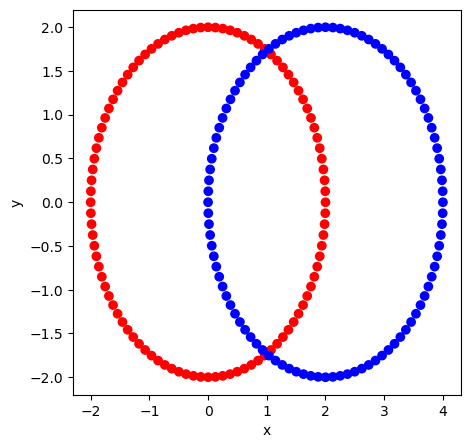

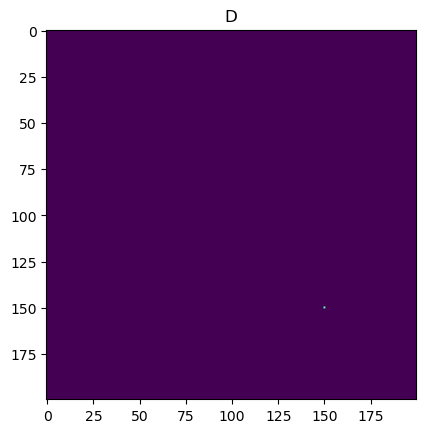

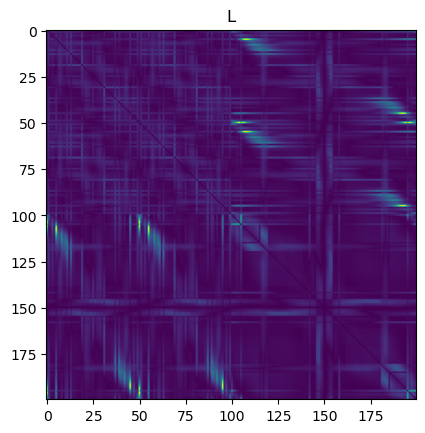

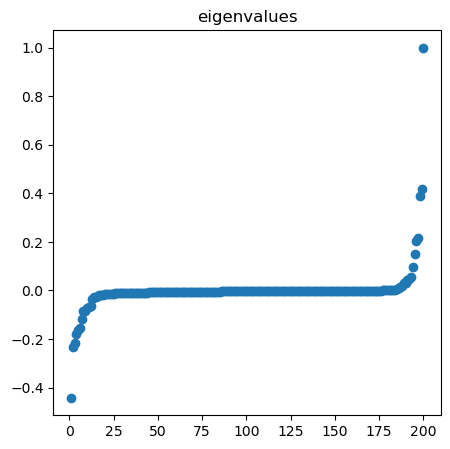

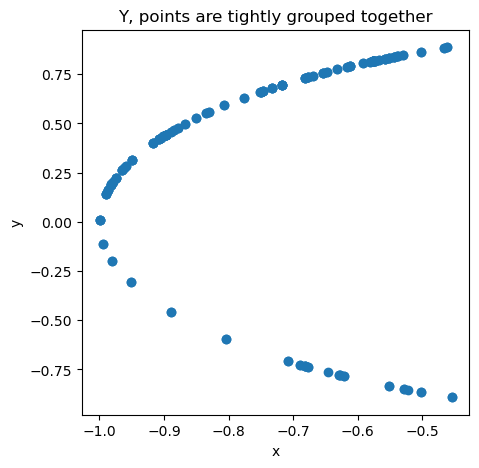

../05_toy_problems/07_two_interlocking_circles.tp gamma: 0.235 normalized mutual information score: 0.09 



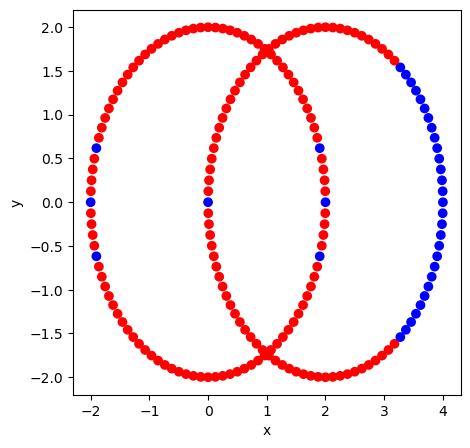

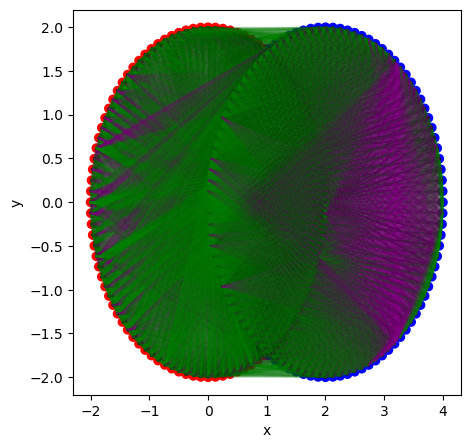

In [18]:
set_K = 0
gamma = 0.235
plotter = True
printer = False
norm_sub = False
extra_plotter = True
save = True
axis_hold = False
subspace_clustering('../05_toy_problems/07_two_interlocking_circles.tp',
                    '../05_toy_problems/03_ground_truth.tp',
                    gamma, set_K, norm_sub, plotter, extra_plotter, printer, save, axis_hold)

In [19]:
set_K = 0
gamma = np.linspace(.001,1,5)
plotter = False
printer = False
norm_sub = False
extra_plotter = False
for i in gamma:
    subspace_clustering('../05_toy_problems/08_two_interlocking_curves.tp',
                        '../05_toy_problems/03_ground_truth.tp',
                        i, set_K, norm_sub, plotter, extra_plotter, printer)

../05_toy_problems/08_two_interlocking_curves.tp gamma: 0.001 normalized mutual information score: 0.0 

../05_toy_problems/08_two_interlocking_curves.tp gamma: 0.251 normalized mutual information score: 0.009 

../05_toy_problems/08_two_interlocking_curves.tp gamma: 0.5 normalized mutual information score: 0.0 

../05_toy_problems/08_two_interlocking_curves.tp gamma: 0.75 normalized mutual information score: 0.0 

../05_toy_problems/08_two_interlocking_curves.tp gamma: 1.0 normalized mutual information score: 0.0 



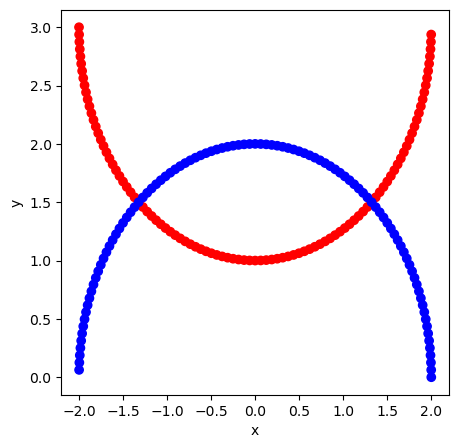

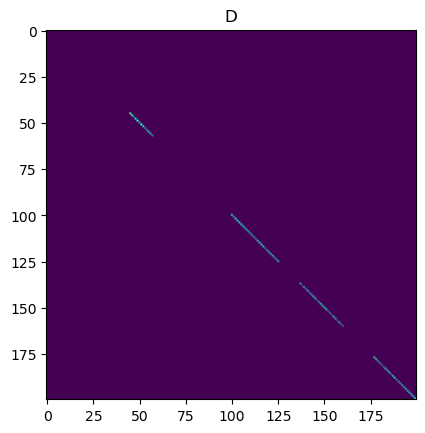

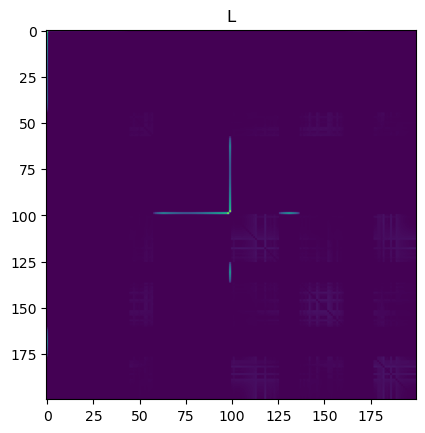

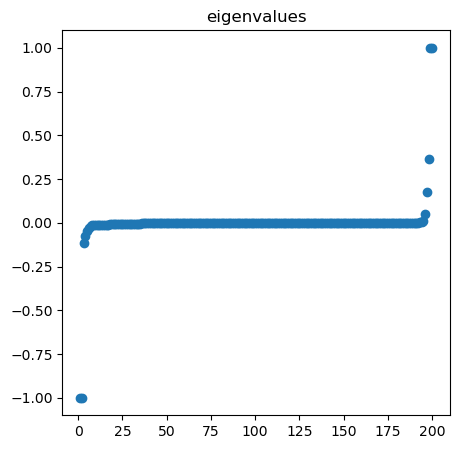

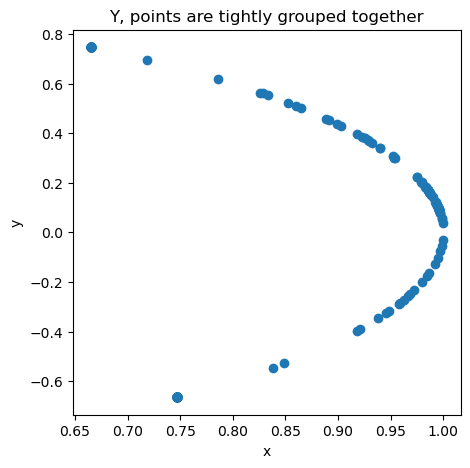

../05_toy_problems/08_two_interlocking_curves.tp gamma: 0.286 normalized mutual information score: 0.015 



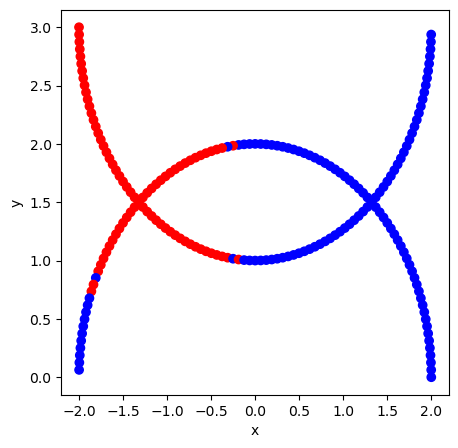

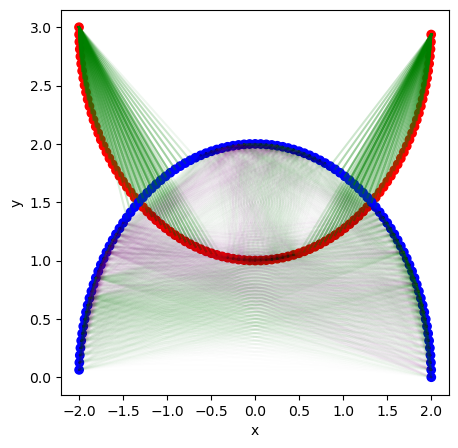

In [20]:
set_K = 0
gamma = 0.286
plotter = True
printer = False
norm_sub = False
extra_plotter = True
save = True
axis_hold = False
subspace_clustering('../05_toy_problems/08_two_interlocking_curves.tp',
                    '../05_toy_problems/03_ground_truth.tp',
                    gamma, set_K, norm_sub, plotter, extra_plotter, printer, save, axis_hold)

In [21]:
set_K = 0
gamma = np.linspace(.5,10,5)
plotter = False
printer = False
norm_sub = False
extra_plotter = False
for i in gamma:
    subspace_clustering('../05_toy_problems/09_two_subset_circles.tp',
                        '../05_toy_problems/03_ground_truth.tp',
                        i, set_K, norm_sub, plotter, extra_plotter, printer)

../05_toy_problems/09_two_subset_circles.tp gamma: 0.5 normalized mutual information score: 0.0 

../05_toy_problems/09_two_subset_circles.tp gamma: 2.875 normalized mutual information score: 0.0 

../05_toy_problems/09_two_subset_circles.tp gamma: 5.25 normalized mutual information score: 0.0 

../05_toy_problems/09_two_subset_circles.tp gamma: 7.625 normalized mutual information score: 0.0 

../05_toy_problems/09_two_subset_circles.tp gamma: 10.0 normalized mutual information score: 0.0 



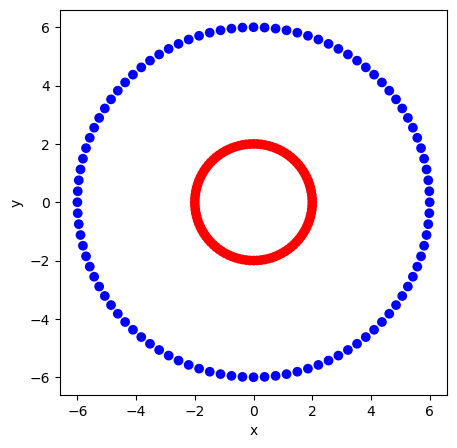

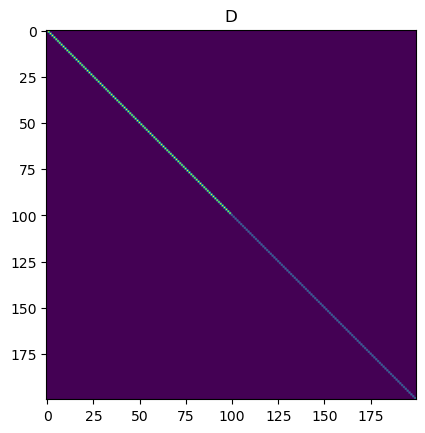

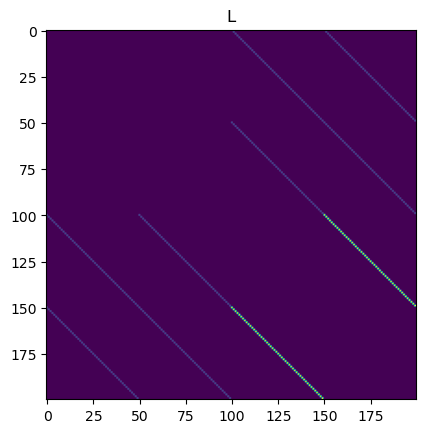

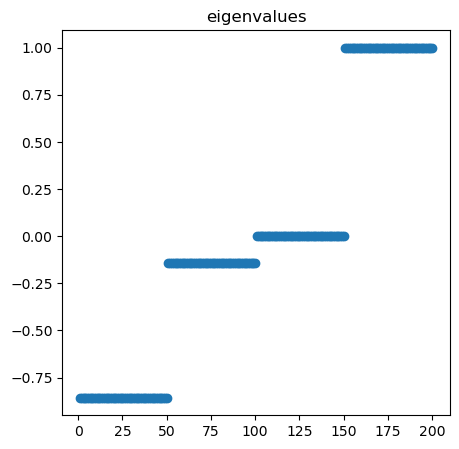

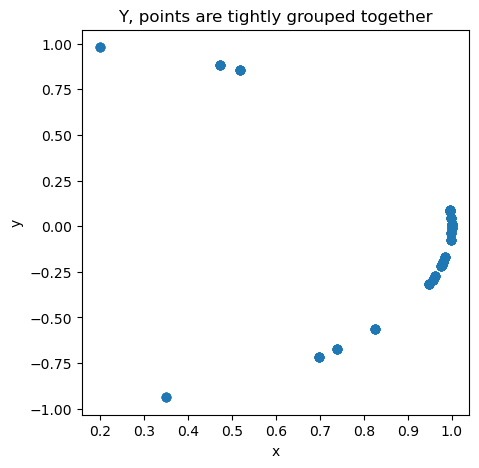

../05_toy_problems/09_two_subset_circles.tp gamma: 0.5 normalized mutual information score: 0.0 



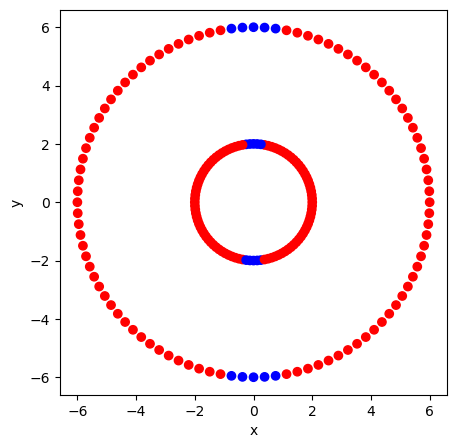

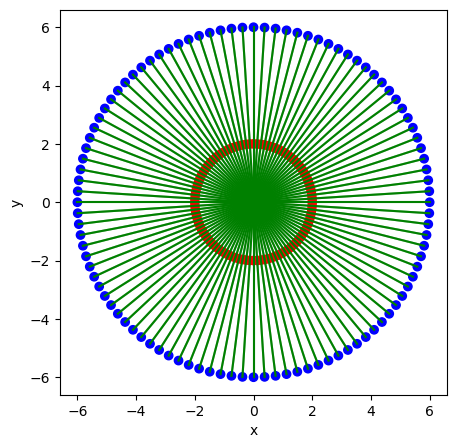

In [22]:
set_K = 0
gamma = 0.5
plotter = True
printer = False
norm_sub = False
extra_plotter = True
save = True
axis_hold = False
subspace_clustering('../05_toy_problems/09_two_subset_circles.tp',
                    '../05_toy_problems/03_ground_truth.tp',
                    gamma, set_K, norm_sub, plotter, extra_plotter, printer, save, axis_hold)

In [23]:
set_K = 0
gamma = np.linspace(1,10,5)
plotter = False
printer = False
norm_sub = False
extra_plotter = False
for i in gamma:
    subspace_clustering('../05_toy_problems/10_x.tp',
                        '../05_toy_problems/03_ground_truth.tp',
                        i, set_K, norm_sub, plotter, extra_plotter, printer)

../05_toy_problems/10_x.tp gamma: 1.0 normalized mutual information score: 0.96 

../05_toy_problems/10_x.tp gamma: 3.25 normalized mutual information score: 0.96 

../05_toy_problems/10_x.tp gamma: 5.5 normalized mutual information score: 0.96 

../05_toy_problems/10_x.tp gamma: 7.75 normalized mutual information score: 0.96 

../05_toy_problems/10_x.tp gamma: 10.0 normalized mutual information score: 0.96 



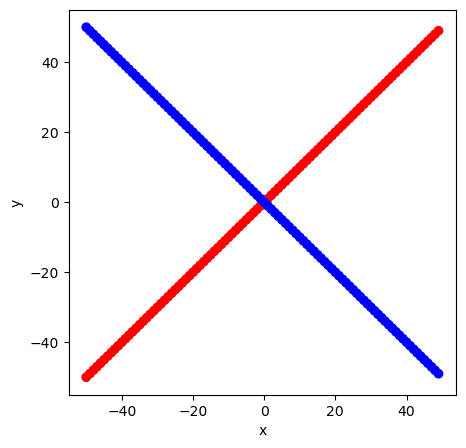

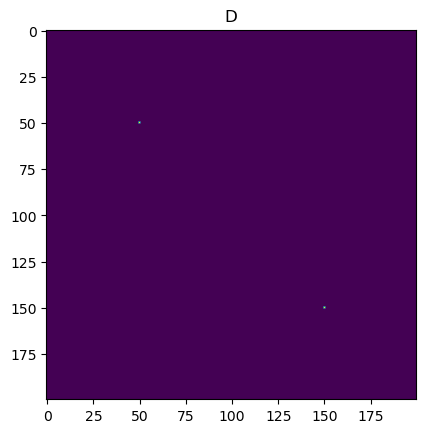

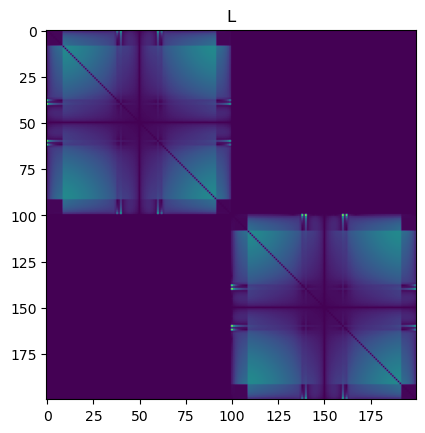

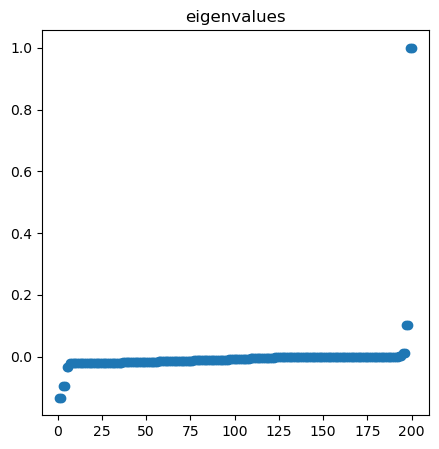

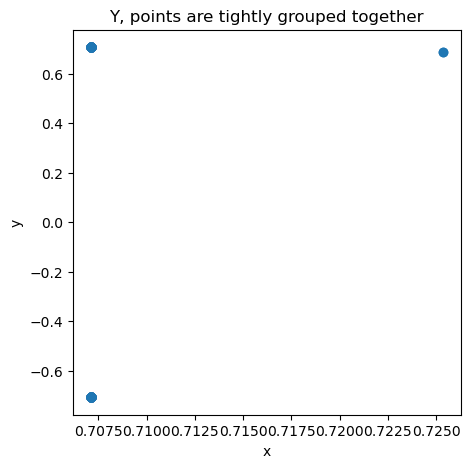

../05_toy_problems/10_x.tp gamma: 0.01 normalized mutual information score: 0.96 



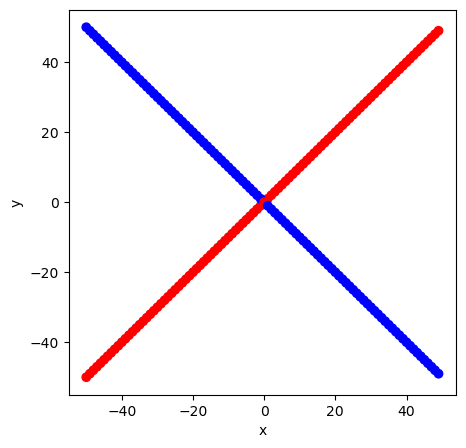

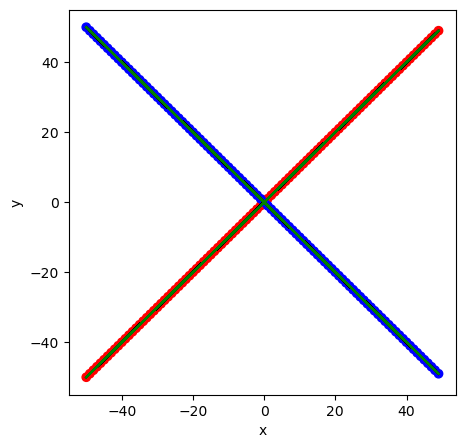

In [24]:
set_K = 0
gamma = 0.01
plotter = True
printer = False
norm_sub = False
extra_plotter = True
save = True
axis_hold = False
subspace_clustering('../05_toy_problems/10_x.tp',
                    '../05_toy_problems/03_ground_truth.tp',
                    gamma, set_K, norm_sub, plotter, extra_plotter, printer, save, axis_hold)

In [25]:
set_K = 0
gamma = np.linspace(.1,1,20)
plotter = False
printer = False
norm_sub = False
extra_plotter = False
for i in gamma:
    subspace_clustering('../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds',
                        '../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1_ground_truth.ds',
                        i, set_K, norm_sub, plotter, extra_plotter, printer)

../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds gamma: 0.1 normalized mutual information score: 0.045 

../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds gamma: 0.147 normalized mutual information score: 0.064 

../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds gamma: 0.195 normalized mutual information score: 1.0 

../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds gamma: 0.242 normalized mutual information score: 1.0 

../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds gamma: 0.289 normalized mutual information score: 1.0 

../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds gamma: 0.337 normalized mutual information score: 1.0 

../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds gamma: 0.384 normalized mutual information score: 1.0 

../06_datasets/01_binary_alpha_digits/02_binary_alpha_digits_0_and_1.ds gamma: 0.432 normalized mutual

In [26]:
set_K = 0
gamma = np.linspace(.1,1,20)
plotter = False
printer = False
norm_sub = False
extra_plotter = False
for i in gamma:
    subspace_clustering('../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds',
                        '../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8_ground_truth.ds',
                        i, set_K, norm_sub, plotter, extra_plotter, printer)

../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds gamma: 0.1 normalized mutual information score: 0.045 

../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds gamma: 0.147 normalized mutual information score: 0.064 

../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds gamma: 0.195 normalized mutual information score: 0.064 

../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds gamma: 0.242 normalized mutual information score: 1.0 

../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds gamma: 0.289 normalized mutual information score: 1.0 

../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds gamma: 0.337 normalized mutual information score: 1.0 

../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds gamma: 0.384 normalized mutual information score: 1.0 

../06_datasets/01_binary_alpha_digits/03_binary_alpha_digits_0_and_8.ds gamma: 0.432 normalized mutu

In [ ]:
set_K = 0
gamma = np.linspace(1,10,20)
plotter = False
printer = False
norm_sub = False
extra_plotter = False
for i in gamma:
    subspace_clustering('../06_datasets/01_binary_alpha_digits/01_binary_alpha_digits.ds',
                        '../06_datasets/01_binary_alpha_digits/01_binary_alpha_digits_ground_truth.ds',
                        i, set_K, norm_sub, plotter, extra_plotter, printer)